# FashFusion — 전처리 통합 노트북

---

## 프로젝트 개요
- **팀명**: QuadrupleNet
- **모델명**: FashFusion
- **목표**: 장바구니 아이템 조합 → 구매 전환 확률 예측

## 모델 구조

## 사용 데이터
| 데이터 | 용도 | 다운로드 |
|---|---|---|
| Polyvore | 코디 적합도 사전학습 (Stage 1) | https://github.com/xthan/polyvore-dataset |
| Polyvore 이미지 | 상품 이미지 | https://www.kaggle.com/datasets/dnepozitek/maryland-polyvore-images/data |
| H&M | 구매 전환 파인튜닝 (Stage 2) | https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations/data |

- 데이터가 아래 상태로 있어야함
- hnm은 데이터 용량이 커서 캐글 웹사이트에서 받는것 추천...
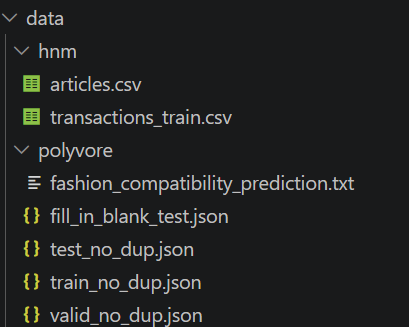

```
[이미지] → MobileNetV2  → img_emb (1280d)
                                        ↓ concat → item_emb
[텍스트] → DistilBERT   → txt_emb (768d)
                                        ↓
                             Late Fusion MLP
                                        ↓
                             구매 전환 확률 (0~1)
```

## 현재 데이터 & 필요한 것
```
bdp/data/
├── hnm/
│   ├── articles.csv             ✅ 보유
│   ├── transactions_train.csv   ✅ 보유
│   └── images/                  ⬇️ 아래 셀에서 다운로드 (34GB)/(캐글에서 직접 다운 받아도됨)  
│       ├── 010/
│       └── ...
└── polyvore/
    ├── train_no_dup.json        ✅ 보유
    ├── valid_no_dup.json        ✅ 보유
    ├── test_no_dup.json         ✅ 보유
    ├── fill_in_blank_test.json  ✅ 보유
    ├── fashion_compatibility_prediction.txt ✅ 보유
    └── images/                  ⬇️ 아래 셀에서 HuggingFace parquet 추출
        └── {item_id}.jpg
```

## 전처리 목표
| 항목 | 처리 방법 |
|---|---|
| 이미지 | 224×224 리사이즈, ImageNet 정규화 (MobileNetV2) |
| 텍스트 | DistilBERT 토크나이징, max_length=128 |
| 결측 이미지 | 데이터셋에서 즉시 제거 |
| Negative Sampling | 같은 카테고리 다른 아이템으로 교체 (label=0) |
| 클래스 불균형 | Stratified K-Fold(K=5) 인덱스 저장 |

---

## 라이브러리 설치

In [3]:
!pip install transformers torch torchvision Pillow tqdm scikit-learn kagglehub huggingface_hub datasets

^C


  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   -- ------------------------------------- 8.1/114.5 MB 41.8 MB/s eta 0:00:03
   --- ------------------------------------ 10.2/114.5 MB 27.7 MB/s eta 0:00:04
   ---- ----------------------------------- 13.4/114.5 MB 21.5 MB/s eta 0:00:05
   ----- ---------------------------------- 16.0/114.5 MB 19.3 MB/s eta 0:00:06
   ------ --------------------------------- 18.9/114.5 MB 17.8 MB/s eta 0:00:06
   ------- -------------------------------- 22.0/114.5 MB 17.4 MB/s eta 0:00:06
   -------- ------------------------------- 25.2/114.5 MB 17.0 MB/s eta 0:00:06
   --------- ------------------------------ 28.0/114.5 MB 16.5 MB/s eta 0:00:06
   ---------- ----------------------------- 31.2/114.5 MB 16.4 MB/s eta 0:00:06
   ----------- -------

## 라이브러리 import

In [4]:
import json, random, pickle, io, shutil
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from transformers import DistilBertTokenizer
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

random.seed(42)
np.random.seed(42)
print('라이브러리 로드 완료')

c:\Users\renee\anaconda3\envs\tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Using cached torch-2.11.0-cp310-cp310-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
Using cached torch-2.11.0-cp310-cp310-win_amd64.whl (114.5 MB)
Using cached torchvision-0.26.0-cp310-cp310-win_amd64.whl (3.7 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 

ERROR: Could not install packages due to an OSError: [WinError 5] 액세스가 거부되었습니다: 'C:\\Users\\renee\\anaconda3\\envs\\tf\\Lib\\site-packages\\torchvision\\_C.pyd'
Consider using the `--user` option or check the permissions.



라이브러리 로드 완료


## 공통 설정

In [5]:
# ── 경로 ────────────────────────────────────────────────────
BASE_DIR      = Path('./data')
POLYVORE_DIR  = BASE_DIR / 'polyvore'
POLYVORE_IMG  = POLYVORE_DIR / 'images'
HNM_DIR       = BASE_DIR / 'hnm'
HNM_IMG       = HNM_DIR / 'images'
OUTPUT_DIR    = Path('./output')

for p in [POLYVORE_IMG, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ── 하이퍼파라미터 ───────────────────────────────────────────
MAX_LENGTH      = 128
IMG_SIZE        = 224
MAX_HNM_OUTFITS = 50_000

# ── 이미지 전처리 (MobileNetV2) ──────────────────────────────
image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ── DistilBERT 토크나이저 ────────────────────────────────────
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(texts):
    enc = tokenizer(
        texts, padding='max_length', truncation=True,
        max_length=MAX_LENGTH, return_tensors='pt'
    )
    return enc['input_ids'], enc['attention_mask']

print(f'설정 완료 | 이미지: {IMG_SIZE}x{IMG_SIZE} | max_length: {MAX_LENGTH}')

c:\Users\renee\anaconda3\envs\tf\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\renee\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


설정 완료 | 이미지: 224x224 | max_length: 128


---
# ▼ 데이터 다운로드

---
## [다운로드 1] H&M 이미지 — Kaggle (34GB)
> **사전 준비**: Kaggle 계정 → Settings → API → Create New Token  
> 받은 `kaggle.json`을 `~/.kaggle/kaggle.json` 에 저장 후 실행

In [ ]:
if not HNM_IMG.exists() or not any(HNM_IMG.iterdir()):
    import kagglehub
    print('H&M 이미지 다운로드 중... (34GB, 시간 많이 걸림)')
    path = kagglehub.competition_download(
        'h-and-m-personalized-fashion-recommendations'
    )
    src = Path(path) / 'images'
    if src.exists():
        shutil.move(str(src), str(HNM_IMG))
        print(f'완료 → {HNM_IMG}')
    else:
        print(f'images 폴더를 수동으로 {HNM_IMG} 에 복사하세요')
else:
    print(f'H&M 이미지 이미 존재 → {HNM_IMG}')

## [다운로드 2] Polyvore 이미지 — HuggingFace parquet에서 추출 (4.3GB)
> **사전 준비**: https://huggingface.co/datasets/mvasil/polyvore-outfits 에서 Access Request 승인 받기  
> 터미널에서 `huggingface-cli login` 실행 후 토큰 입력 (토큰: https://huggingface.co/settings/tokens)

In [ ]:
import os, json

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

creds = {"username":"","key":""}  # key 전체 붙여넣기
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(creds, f)

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('완료')

완료


In [12]:
if not POLYVORE_IMG.exists() or not any(POLYVORE_IMG.iterdir()):
    from datasets import load_dataset

    print('HuggingFace에서 Polyvore parquet 로드 중... (4.3GB)')
    ds = load_dataset('mvasil/polyvore-outfits', 'disjoint')

    print('이미지 추출 & 저장 중...')
    saved = 0
    for split in ['train', 'validation', 'test']:
        for row in tqdm(ds[split], desc=f'  {split}'):
            item_id  = str(row['item_id'])
            img_data = row.get('image')
            if img_data is None: continue
            out_path = POLYVORE_IMG / f'{item_id}.jpg'
            if out_path.exists(): continue
            if isinstance(img_data, bytes):
                img = Image.open(io.BytesIO(img_data)).convert('RGB')
            else:
                img = img_data.convert('RGB')
            img.save(out_path, 'JPEG')
            saved += 1

    print(f'완료 → {saved:,}개 저장 → {POLYVORE_IMG}')
else:
    print(f'Polyvore 이미지 이미 존재 → {POLYVORE_IMG}')

HuggingFace에서 Polyvore parquet 로드 중... (4.3GB)


DatasetNotFoundError: Dataset 'mvasil/polyvore-outfits' is a gated dataset on the Hub. You must be authenticated to access it.

---
# ① POLYVORE 전처리 (Stage 1 — 코디 적합도 사전학습)

---
## [Polyvore] STEP 1 — JSON 로드 & 아이템 ID 생성
`set_id + index` → `set_id_index` 고유 ID

In [ ]:
def load_outfits(path):
    with open(path, 'r') as f:
        return json.load(f)

def parse_items(outfits):
    rows = []
    for outfit in outfits:
        set_id = outfit['set_id']
        for item in outfit.get('items', []):
            rows.append({
                'item_id'    : f"{set_id}_{item['index']}",
                'set_id'     : set_id,
                'name'       : item.get('name', ''),
                'categoryid' : item.get('categoryid', -1),
            })
    return pd.DataFrame(rows)

poly_outfits = load_outfits(POLYVORE_DIR / 'train_no_dup.json')
poly_items   = parse_items(poly_outfits)
print(f'outfit: {len(poly_outfits):,}개 / item: {len(poly_items):,}개')
poly_items.head(3)

## [Polyvore] STEP 2 — 텍스트 토크나이징 (DistilBERT)

In [ ]:
texts      = poly_items['name'].tolist()
ids, masks = tokenize(texts)
torch.save({'input_ids': ids, 'attention_mask': masks},
           OUTPUT_DIR / 'poly_text_tokens.pt')
print(f'shape: {ids.shape} → 저장 완료')

## [Polyvore] STEP 3 — 이미지 전처리 (MobileNetV2)
경로: `polyvore/images/{item_id}.jpg` | 결측 이미지 즉시 제거

In [ ]:
poly_image_tensors = {}
valid_poly_ids     = set()

for item_id in tqdm(poly_items['item_id'], desc='Polyvore 이미지'):
    img_path = POLYVORE_IMG / f'{item_id}.jpg'
    if not img_path.exists(): continue
    t = image_transform(Image.open(img_path).convert('RGB'))
    poly_image_tensors[item_id] = t
    valid_poly_ids.add(item_id)

poly_items = poly_items[poly_items['item_id'].isin(valid_poly_ids)].reset_index(drop=True)
torch.save(poly_image_tensors, OUTPUT_DIR / 'poly_image_tensors.pt')
print(f'이미지: {len(poly_image_tensors):,}개 | 유효 아이템: {len(poly_items):,}개')

## [Polyvore] STEP 4 — Positive / Negative Sampling
- Positive (label=1): 원본 코디 outfit
- Negative (label=0): 같은 카테고리 다른 아이템으로 교체

In [ ]:
cat2items = defaultdict(list)
set2items = defaultdict(list)
for _, row in poly_items.iterrows():
    cat2items[row['categoryid']].append(row['item_id'])
    set2items[row['set_id']].append(row['item_id'])

def make_negative_poly(items):
    items = items.copy()
    random.shuffle(items)
    for i, item in enumerate(items):
        row  = poly_items[poly_items['item_id'] == item]
        if row.empty: continue
        cat  = row.iloc[0]['categoryid']
        pool = [x for x in cat2items[cat] if x != item]
        if not pool: continue
        items[i] = random.choice(pool)
        return items
    return None

poly_dataset = []
for outfit in tqdm(poly_outfits, desc='Polyvore 샘플'):
    pos = set2items.get(outfit['set_id'], [])
    if len(pos) < 2: continue
    poly_dataset.append({'item_ids': pos, 'label': 1})
    neg = make_negative_poly(pos)
    if neg: poly_dataset.append({'item_ids': neg, 'label': 0})

with open(OUTPUT_DIR / 'poly_dataset.pkl', 'wb') as f:
    pickle.dump(poly_dataset, f)

print(f'총: {len(poly_dataset):,} | Pos: {sum(d["label"]==1 for d in poly_dataset):,} | Neg: {sum(d["label"]==0 for d in poly_dataset):,}')

---
# ② H&M 전처리 (Stage 2 — 구매 전환 파인튜닝)

---
## [H&M] STEP 1 — 거래 데이터 로드 & 같은 날 구매 묶기

In [ ]:
tx = pd.read_csv(HNM_DIR / 'transactions_train.csv',
                 parse_dates=['t_dat'], nrows=5_000_000)

outfits = (
    tx.groupby(['customer_id', 't_dat'])['article_id']
    .apply(list).reset_index()
    .rename(columns={'article_id': 'item_ids'})
)
outfits = outfits[outfits['item_ids'].apply(len) >= 2].reset_index(drop=True)
if len(outfits) > MAX_HNM_OUTFITS:
    outfits = outfits.sample(n=MAX_HNM_OUTFITS, random_state=42).reset_index(drop=True)

print(f'유효 outfit: {len(outfits):,}개')

## [H&M] STEP 2 — 상품 텍스트 합치기 + TPO 키워드 추출

In [ ]:
articles = pd.read_csv(HNM_DIR / 'articles.csv')

TPO_KEYWORDS = ['casual','formal','sport','outdoor','office',
                'party','beach','summer','winter','evening']

def extract_tpo(text):
    if not isinstance(text, str): return ''
    found  = [kw for kw in TPO_KEYWORDS if kw in text.lower()]
    return (' '.join(found) + ' ' if found else '') + text

articles['text'] = (
    articles['product_type_name'].fillna('') + ' ' +
    articles['colour_group_name'].fillna('') + ' ' +
    articles['section_name'].fillna('')      + ' ' +
    articles['detail_desc'].apply(extract_tpo)
).str.strip()

article_text = articles.set_index('article_id')['text'].to_dict()
print(f'상품: {len(articles):,}개')
print(f'샘플: {list(article_text.values())[0][:100]}...')

## [H&M] STEP 3 — DistilBERT 토크나이징

In [ ]:
used_ids = list(set(aid for ids in outfits['item_ids']
                    for aid in ids if aid in article_text))
print(f'토크나이징: {len(used_ids):,}개')

BATCH = 512
hnm_token_dict = {}
for i in tqdm(range(0, len(used_ids), BATCH), desc='H&M 토크나이징'):
    batch_ids   = used_ids[i:i+BATCH]
    batch_texts = [article_text[aid] for aid in batch_ids]
    ids, masks  = tokenize(batch_texts)
    for j, aid in enumerate(batch_ids):
        hnm_token_dict[aid] = {'input_ids': ids[j], 'attention_mask': masks[j]}

torch.save(hnm_token_dict, OUTPUT_DIR / 'hnm_text_tokens.pt')
print('저장 완료')

## [H&M] STEP 4 — 이미지 전처리 (MobileNetV2)
경로: `hnm/images/{앞3자리}/{article_id}.jpg` | 결측 이미지 즉시 제거

In [ ]:
hnm_image_tensors = {}
valid_hnm_ids     = set()

for aid in tqdm(used_ids, desc='H&M 이미지'):
    aid_str  = str(aid).zfill(10)
    img_path = HNM_IMG / aid_str[:3] / f'{aid_str}.jpg'
    if not img_path.exists(): continue
    t = image_transform(Image.open(img_path).convert('RGB'))
    hnm_image_tensors[aid] = t
    valid_hnm_ids.add(aid)

outfits['item_ids'] = outfits['item_ids'].apply(
    lambda ids: [x for x in ids if x in valid_hnm_ids]
)
outfits = outfits[outfits['item_ids'].apply(len) >= 2].reset_index(drop=True)

torch.save(hnm_image_tensors, OUTPUT_DIR / 'hnm_image_tensors.pt')
print(f'이미지: {len(hnm_image_tensors):,}개 | 유효 outfit: {len(outfits):,}개')

## [H&M] STEP 5 — Positive / Negative Sampling

In [ ]:
id_to_cat   = articles.set_index('article_id')['product_type_name'].to_dict()
hnm_cat2ids = (
    articles[articles['article_id'].isin(valid_hnm_ids)]
    .groupby('product_type_name')['article_id']
    .apply(list).to_dict()
)

def make_negative_hnm(item_ids):
    items = item_ids.copy()
    random.shuffle(items)
    for i, aid in enumerate(items):
        cat  = id_to_cat.get(aid)
        if not cat: continue
        pool = [x for x in hnm_cat2ids.get(cat, []) if x != aid]
        if not pool: continue
        items[i] = random.choice(pool)
        return items
    return None

hnm_dataset = []
for _, row in tqdm(outfits.iterrows(), total=len(outfits), desc='H&M 샘플'):
    pos = row['item_ids']
    hnm_dataset.append({'item_ids': pos, 'label': 1})
    neg = make_negative_hnm(pos)
    if neg: hnm_dataset.append({'item_ids': neg, 'label': 0})

print(f'총: {len(hnm_dataset):,} | Pos: {sum(d["label"]==1 for d in hnm_dataset):,} | Neg: {sum(d["label"]==0 for d in hnm_dataset):,}')

## [H&M] STEP 6 — Stratified K-Fold (K=5)

In [ ]:
labels = np.array([d['label'] for d in hnm_dataset])
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_indices = []
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    fold_indices.append({'train': train_idx.tolist(), 'val': val_idx.tolist()})
    print(f'Fold {fold+1}: train {len(train_idx):,} / val {len(val_idx):,} | pos ratio: {labels[train_idx].mean():.2f}')

with open(OUTPUT_DIR / 'hnm_dataset.pkl', 'wb') as f:
    pickle.dump({'dataset': hnm_dataset, 'fold_indices': fold_indices}, f)
print(f'저장 완료 → {OUTPUT_DIR}/hnm_dataset.pkl')

---
## 최종 파일 목록 확인

In [ ]:
print('=== 생성된 파일 ===')
for f in sorted(OUTPUT_DIR.iterdir()):
    stage = 'Stage1 (Polyvore)' if 'poly' in f.name else 'Stage2 (H&M)'
    print(f'  [{stage}] {f.name:40s} {f.stat().st_size/1e6:.1f} MB')
print('\n✅ 전처리 완료!')